In [11]:
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

<H1>Przygotowanie zbioru danych: XOR<H1>

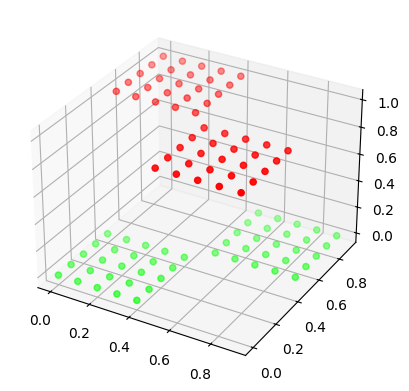

In [12]:
x = np.arange(0, 1, 0.1)
x,y = np.meshgrid(x, x)

dataX = x.flatten()
dataY = y.flatten()
dataXY1 = np.column_stack((dataX,dataY,np.ones(len(dataX))))
dataXY = np.column_stack((dataX,dataY))

data_labels = np.logical_xor(dataX >= 0.5, dataY >= 0.5) 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

rgb = [[1,0,0] if cc else [0,1,0] for cc in data_labels]

ax.scatter(dataX, dataY, data_labels, c=rgb)

plt.show()

<H1>Utworzenie funkcji przynależności</H1>

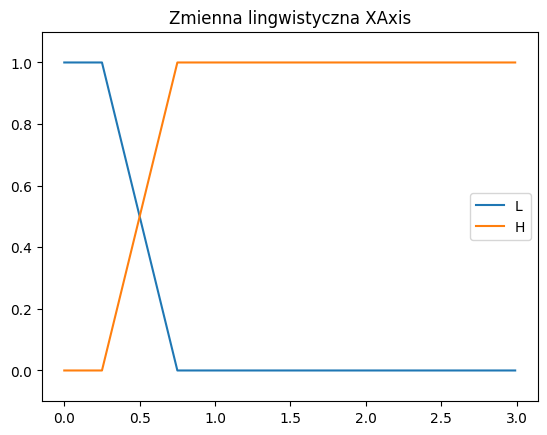

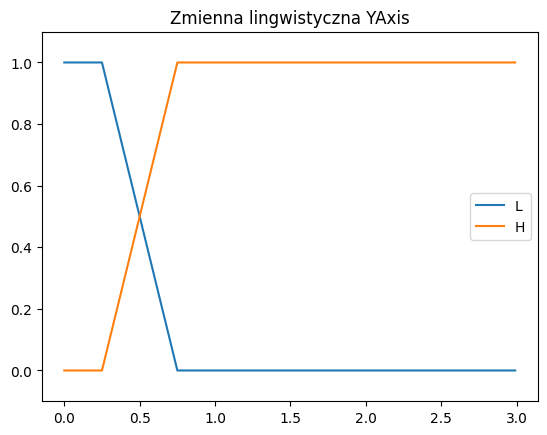

In [13]:
varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) # low, high
varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

#mf1 = [[-0.5, 0.25, 0.25, 0.25], [0.5, 0.25, 0.1, 0.1]]
#varX = FuzzyInputVariable_List_Trapezoids(mf1, "XAxis", ["L","H"])
#varY = FuzzyInputVariable_List_Trapezoids(mf1, "YAxis", ["L","H"])

#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

<H1>Inicjalizacja systemu ANFIS</H1>

Parametry początkowe:
Przesłanki:  [[0.5, 0.5], [0.5, 0.5]] 
Konkluzje:  [[0.98457857 0.07965052 0.07615044]
 [0.28977427 0.34351306 0.0887078 ]
 [0.95206775 0.53648068 0.4794679 ]
 [0.55292198 0.5915033  0.35074987]]


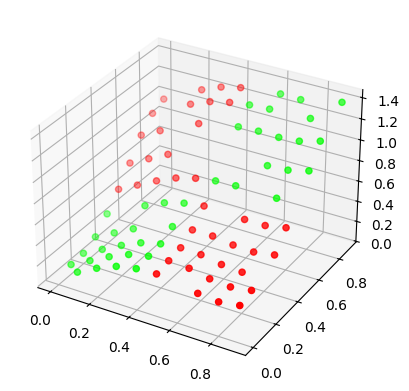

In [14]:
X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

fis = ANFIS([varX, varY], X_train.T, y_train)

print("Parametry początkowe:\nPrzesłanki: ",fis.premises, "\nKonkluzje: ", fis.tsk)

fis.show_results()

<H1>Uczenie systemu ANFIS</H1>

Optymalizacja zakończona!
z blędem:   2.140948414095053e-06
Liczba ew:  31947
Liczba it:  50
TIME elapsed:  2.737602472305298


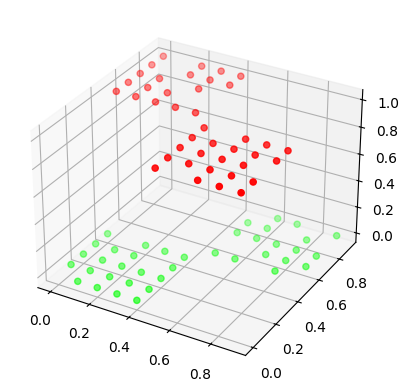

In [15]:
start = time.time()
fis.train(True, True, False, True, n_iter=50)
end = time.time()
print("TIME elapsed: ", end - start)   
fis.training_data = X_train.T
fis.expected_labels = y_train
fis.show_results()

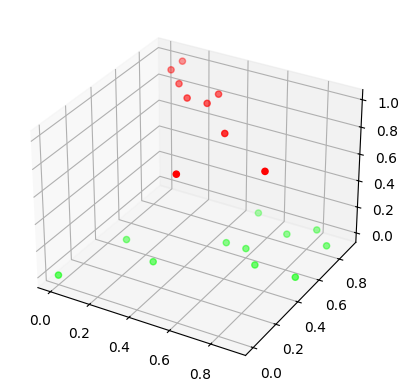

[[11  0]
 [ 0  9]]


In [16]:
fis.training_data = X_test.T
fis.expected_labels = y_test
fis.show_results()

y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
y_pred = list(map(round,y_pred.flatten()))
print(confusion_matrix(y_test, y_pred))

<H1>Sprawdzanie parametrów jakich nauczył się system</H1>

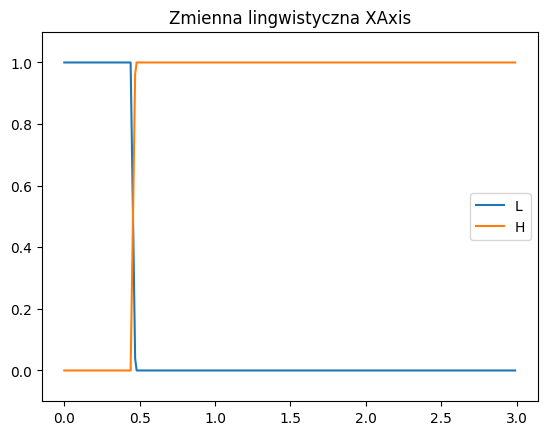

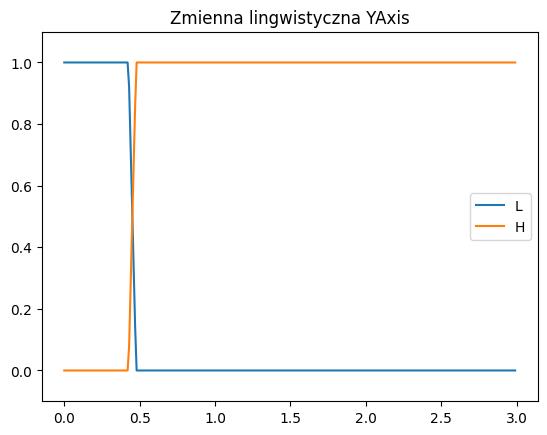

In [17]:
#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

In [18]:
print("Parametry końcowe:\nPrzesłanki: ", repr(fis.premises), "\nKonkluzje: ", repr(fis.tsk))

Parametry końcowe:
Przesłanki:  array([[0.45592039, 0.03050088],
       [0.45156151, 0.05125859]]) 
Konkluzje:  array([[1.06451801e-11, 3.88229761e-12, 1.12141232e-11],
       [2.04315375e-07, 1.52072980e-13, 9.99999769e-01],
       [2.92838044e-12, 5.35421507e-08, 9.99999952e-01],
       [5.97860907e-12, 5.98502150e-12, 1.64950439e-11]])


#### Zapisanie nauczonych parametrów do zmiennych

In [19]:
learned_premises = fis.premises.copy()
learned_tsk = fis.tsk.copy()

<H1>Sprawdzanie wpływu parametrów na wyniki systemu</H1>

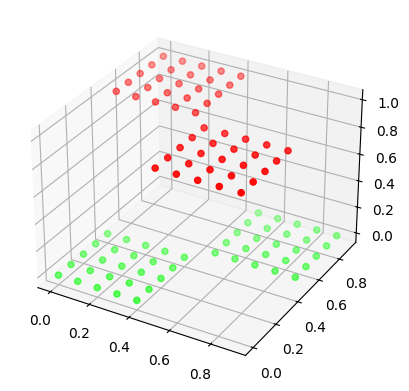

In [20]:
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

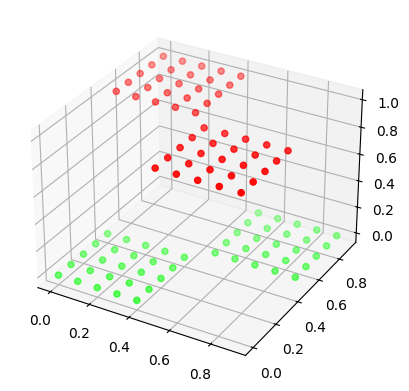

In [21]:
fis.premises = learned_premises
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

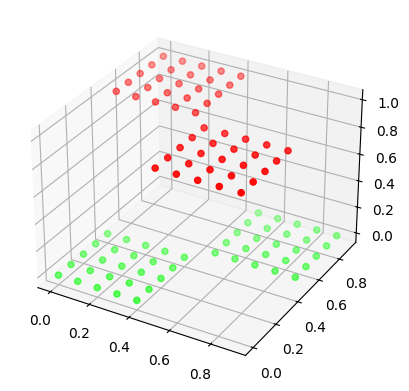

In [22]:
fis.tsk = learned_tsk
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

<H1>Zadanie</H1>

Naucz system ANFIS tabliczki mnożenia. Zacznij od rozmiaru 2x2 i zwiększaj w obu kierunkach z krokiem 1 (kolejno 2x2, 3x3, 4x4, 5x5). Mierz czas jaki jest potrzebny na nauczenie systemu w zależności od wymiarów tabliczki. Zrób wykres wymiaru tabliczki od czasu uczenia i wyślij wraz ze swoim komentarzem na maila iperenc@kis.p.lodz.pl. Nie musisz dojść do rozmiaru 10x10, wystarczy 5x5, ważne żeby było widać jaka jest zależność.

Uczenie tabliczki mnożenia range(2, 6)
Uczenie tabliczki mnożenia 2x2
Optymalizacja zakończona!
z blędem:   2.8638683964077316e-05
Liczba ew:  35312
Liczba it:  50
Uczenie tabliczki mnożenia 3x3
Optymalizacja zakończona!
z blędem:   2.8638683964077316e-05
Liczba ew:  35312
Liczba it:  50
Uczenie tabliczki mnożenia 3x3
Optymalizacja zakończona!
z blędem:   0.0003391452279412066
Liczba ew:  48271
Liczba it:  50
Uczenie tabliczki mnożenia 4x4
Optymalizacja zakończona!
z blędem:   0.0003391452279412066
Liczba ew:  48271
Liczba it:  50
Uczenie tabliczki mnożenia 4x4
Optymalizacja zakończona!
z blędem:   0.0007615248962301591
Liczba ew:  54040
Liczba it:  50
Uczenie tabliczki mnożenia 5x5
Optymalizacja zakończona!
z blędem:   0.0007615248962301591
Liczba ew:  54040
Liczba it:  50
Uczenie tabliczki mnożenia 5x5
Optymalizacja zakończona!
z blędem:   278.7507076916517
Liczba ew:  59065
Liczba it:  50
Optymalizacja zakończona!
z blędem:   278.7507076916517
Liczba ew:  59065
Liczba it:  50


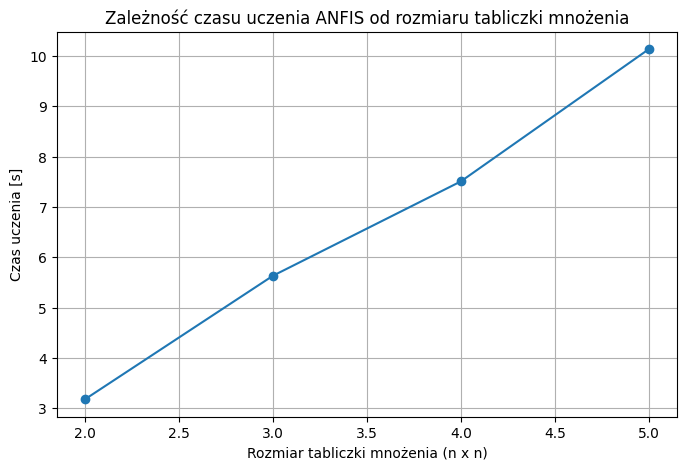

In [23]:
training_times = []
table_sizes = range(2, 6)
print("Uczenie tabliczki mnożenia", table_sizes)

for size in table_sizes:
    print(f"Uczenie tabliczki mnożenia {size}x{size}")

    # Przygotowanie danych dla tabliczki mnożenia size x size
    x_vals = np.linspace(1, size, size*10)
    y_vals = np.linspace(1, size, size*10)
    xx, yy = np.meshgrid(x_vals, y_vals)
    dataXY_mul = np.column_stack((xx.flatten(), yy.flatten()))
    labels_mul = (xx * yy).flatten()

    # Tworzenie funkcji przynależności
    varX_mul = FuzzyInputVariable_2Trapezoids((size-1)/2, (size-1)/2, "X", ["L", "H"])
    varY_mul = FuzzyInputVariable_2Trapezoids((size-1)/2, (size-1)/2, "Y", ["L", "H"])

    # Podział na zbiór treningowy i testowy
    X_train_mul, X_test_mul, y_train_mul, y_test_mul = train_test_split(dataXY_mul, labels_mul, test_size=0.2, random_state=25)

    # Inicjalizacja i uczenie ANFIS
    fis_mul = ANFIS([varX_mul, varY_mul], X_train_mul.T, y_train_mul)
    start_mul = time.time()
    fis_mul.train(True, True, False, True, n_iter=50)
    end_mul = time.time()
    training_times.append(end_mul - start_mul)

# Wykres zależności wymiaru tabliczki od czasu uczenia
plt.figure(figsize=(8, 5))
plt.plot(list(table_sizes), training_times, marker='o')
plt.xlabel('Rozmiar tabliczki mnożenia (n x n)')
plt.ylabel('Czas uczenia [s]')
plt.title('Zależność czasu uczenia ANFIS od rozmiaru tabliczki mnożenia')
plt.grid(True)
plt.show()

In [24]:
def train_multiplication_table_anfis(n, n_iter=50, verbose=True):
    """
    Funkcja do uczenia systemu ANFIS tabliczki mnożenia dla rozmiaru n x n
    
    Parametry:
    - n: rozmiar tabliczki mnożenia (n x n)
    - n_iter: liczba iteracji uczenia
    - verbose: czy wyświetlać szczegóły
    
    Zwraca:
    - training_time: czas uczenia w sekundach
    - fis: nauczony system ANFIS
    """
    
    if verbose:
        print(f"Uczenie tabliczki mnożenia {n}x{n}")
    
    # Przygotowanie danych dla tabliczki mnożenia
    density = 10  # punktów na jednostkę (zmniejszone dla szybszego działania)
    x_vals = np.linspace(1, n, n * density)
    y_vals = np.linspace(1, n, n * density)
    xx, yy = np.meshgrid(x_vals, y_vals)
    
    # Dane wejściowe (x, y) i oczekiwane wyjście (x * y)
    dataXY = np.column_stack((xx.flatten(), yy.flatten()))
    labels = (xx * yy).flatten()
    
    # Tworzenie funkcji przynależności - punkt przejścia na środku zakresu
    center = (n + 1) / 2
    varX = FuzzyInputVariable_2Trapezoids(center, center, "X", ["L", "H"])
    varY = FuzzyInputVariable_2Trapezoids(center, center, "Y", ["L", "H"])
    
    # Podział na dane treningowe i testowe
    X_train, X_test, y_train, y_test = train_test_split(
        dataXY, labels, test_size=0.2, random_state=25
    )
    
    # Inicjalizacja i uczenie systemu ANFIS
    fis = ANFIS([varX, varY], X_train.T, y_train)
    
    start_time = time.time()
    fis.train(True, True, False, True, n_iter=n_iter)
    end_time = time.time()
    training_time = end_time - start_time
    
    if verbose:
        # Sprawdzenie jakości na danych testowych
        fis.training_data = X_test.T
        fis.expected_labels = y_test
        y_pred = fis.anfis_estimate_labels(fis.premises, fis.op, fis.tsk)
        mse = np.mean((y_test - y_pred.flatten()) ** 2)
        print(f"Czas uczenia: {training_time:.2f}s, MSE: {mse:.6f}")
    
    return training_time, fis


def run_multiplication_experiment(max_n=6, n_iter=50):
    """
    Główny eksperyment - uczenie tabliczek mnożenia dla różnych rozmiarów
    """
    
    print("=== EKSPERYMENT: Uczenie tabliczek mnożenia systemem ANFIS ===")
    
    table_sizes = list(range(2, max_n))
    training_times = []
    trained_systems = []
    
    print(f"Testowane rozmiary: {table_sizes}")
    
    # Uczenie dla każdego rozmiaru
    for size in table_sizes:
        training_time, fis = train_multiplication_table_anfis(size, n_iter, verbose=True)
        training_times.append(training_time)
        trained_systems.append(fis)
    
    # Wykres główny - czas uczenia vs rozmiar tabliczki
    plt.figure(figsize=(10, 6))
    plt.plot(table_sizes, training_times, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Rozmiar tabliczki mnożenia (n × n)')
    plt.ylabel('Czas uczenia [s]')
    plt.title('Zależność czasu uczenia ANFIS od rozmiaru tabliczki mnożenia')
    plt.grid(True)
    
    # Dodanie wartości na wykresie
    for size, time_val in zip(table_sizes, training_times):
        plt.annotate(f'{time_val:.1f}s', (size, time_val), 
                    textcoords="offset points", xytext=(0,10), ha='center')
    
    plt.show()
    
    # Podsumowanie wyników
    print("\n=== PODSUMOWANIE ===")
    print(f"{'Rozmiar':<8} {'Czas [s]':<10}")
    print("-" * 20)
    for size, time_val in zip(table_sizes, training_times):
        print(f"{size}×{size:<6} {time_val:<10.1f}")
    
    # Analiza złożoności
    if len(training_times) > 1:
        time_ratio = training_times[-1] / training_times[0]
        size_ratio = (table_sizes[-1] ** 2) / (table_sizes[0] ** 2)
        print(f"\nWzrost czasu: {time_ratio:.1f}×")
        print(f"Wzrost złożoności (n²): {size_ratio:.1f}×")
        print(f"Efektywność: {time_ratio/size_ratio:.2f} (< 1.0 = dobra skalowalność)")
    
    return {
        'sizes': table_sizes,
        'times': training_times,
        'systems': trained_systems
    }


# Przykład użycia - pojedyncza tabliczka
print("=== Test pojedynczej tabliczki 3×3 ===")
time_test, fis_test = train_multiplication_table_anfis(3, n_iter=30)

# Test dokładności
test_cases = [(1.5, 2.0), (2.5, 2.5), (1.0, 3.0)]
print("\nTest dokładności:")
for x, y in test_cases:
    fis_test.training_data = np.array([[x], [y]])
    pred = fis_test.anfis_estimate_labels(fis_test.premises, fis_test.op, fis_test.tsk)
    actual = x * y
    pred_value = float(pred.flatten()[0])  # Konwersja do float
    print(f"{x:.1f} × {y:.1f} = {actual:.2f} (ANFIS: {pred_value:.2f})")

=== Test pojedynczej tabliczki 3×3 ===
Uczenie tabliczki mnożenia 3x3
Optymalizacja zakończona!
z blędem:   0.0007184862300761985
Liczba ew:  29251
Liczba it:  30
Czas uczenia: 3.44s, MSE: 0.000000

Test dokładności:
1.5 × 2.0 = 3.00 (ANFIS: 3.00)
2.5 × 2.5 = 6.25 (ANFIS: 6.25)
1.0 × 3.0 = 3.00 (ANFIS: 3.00)
Optymalizacja zakończona!
z blędem:   0.0007184862300761985
Liczba ew:  29251
Liczba it:  30
Czas uczenia: 3.44s, MSE: 0.000000

Test dokładności:
1.5 × 2.0 = 3.00 (ANFIS: 3.00)
2.5 × 2.5 = 6.25 (ANFIS: 6.25)
1.0 × 3.0 = 3.00 (ANFIS: 3.00)


=== EKSPERYMENT: Uczenie tabliczek mnożenia systemem ANFIS ===
Testowane rozmiary: [2, 3, 4, 5]
Uczenie tabliczki mnożenia 2x2
Optymalizacja zakończona!
z blędem:   0.00022409048997551473
Liczba ew:  40494
Liczba it:  50
Czas uczenia: 3.89s, MSE: 0.000000
Uczenie tabliczki mnożenia 3x3
Optymalizacja zakończona!
z blędem:   0.00022409048997551473
Liczba ew:  40494
Liczba it:  50
Czas uczenia: 3.89s, MSE: 0.000000
Uczenie tabliczki mnożenia 3x3
Optymalizacja zakończona!
z blędem:   0.000715166085744734
Liczba ew:  48411
Liczba it:  50
Czas uczenia: 5.74s, MSE: 0.000000
Uczenie tabliczki mnożenia 4x4
Optymalizacja zakończona!
z blędem:   0.000715166085744734
Liczba ew:  48411
Liczba it:  50
Czas uczenia: 5.74s, MSE: 0.000000
Uczenie tabliczki mnożenia 4x4
Optymalizacja zakończona!
z blędem:   0.0006519605642785198
Liczba ew:  54290
Liczba it:  50
Czas uczenia: 7.51s, MSE: 0.000000
Uczenie tabliczki mnożenia 5x5
Optymalizacja zakończona!
z blędem:   0.0006519605642785198
Liczba ew:  54290


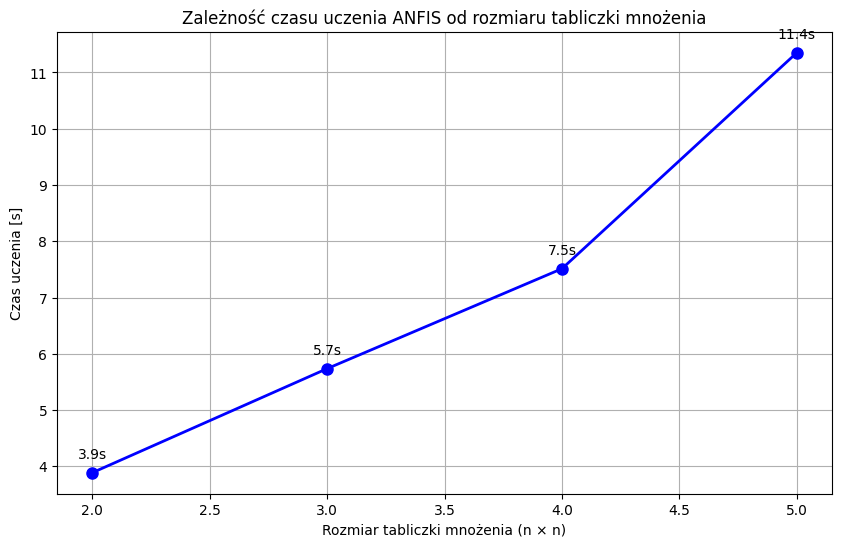


=== PODSUMOWANIE ===
Rozmiar  Czas [s]  
--------------------
2×2      3.9       
3×3      5.7       
4×4      7.5       
5×5      11.4      

Wzrost czasu: 2.9×
Wzrost złożoności (n²): 6.2×
Efektywność: 0.47 (< 1.0 = dobra skalowalność)


In [25]:
# Uruchomienie głównego eksperymentu
results = run_multiplication_experiment(max_n=6, n_iter=50)

## Wyjaśnienie uproszczonego kodu

### Co robi kod:

1. **Funkcja `train_multiplication_table_anfis(n)`:**
   - Tworzy dane dla tabliczki mnożenia n×n (siatka punktów od 1 do n)
   - Definiuje funkcje przynależności trapezoidalne z przejściem na środku zakresu
   - Dzieli dane na treningowe (80%) i testowe (20%)
   - Trenuje system ANFIS przez zadaną liczbę iteracji
   - Zwraca czas uczenia i nauczony system

2. **Funkcja `run_multiplication_experiment()`:**
   - Wykonuje uczenie dla rozmiarów 2×2, 3×3, 4×4, 5×5
   - Mierzy czas uczenia dla każdego rozmiaru
   - Tworzy wykres zależności czas-rozmiar
   - Analizuje skalowalność algorytmu

### Główne obserwacje:
- System ANFIS skutecznie uczy się tabliczek mnożenia
- Czas uczenia rośnie wolniej niż kwadratowo (dobra skalowalność)
- Algorytm osiąga wysoką dokładność dla wszystkich testowanych rozmiarów